In [1]:
import pandas as pd
import numpy as np
from collections import defaultdict, deque
from scipy.optimize import linear_sum_assignment
from tqdm.contrib.concurrent import process_map
from functools import partial
import networkx as nx
import random
from pyreadr import read_r
import heapq
import json


In [2]:
# name mapping
def map_names(did):
    """ Re-map cells to use their 'name' given their 'did'. Only applies to a
        few select cells where the tracker uses their 'name' instead of 'did'.
    """
    if   did == "P4a": return "Z3"
    elif did == "P4p": return "Z2"
    elif did == "P0a": return "AB"
    else: return did

def load_json(file_path):
    """
    Load a JSON file and return its content as a Python object.
    
    :param file_path: Path to the JSON file.
    :return: Parsed JSON content as a Python object.
    """
    with open(file_path, 'r', encoding='utf-8') as file:
        return json.load(file)
    
lineage_data = load_json('./data/cell_lineage.json')

In [3]:
terminal_nodes = []
terminal_parents = []
terminal_parents_dict = defaultdict(list)
terminal_ancestry = defaultdict(list)
def dfs(node, parent, ancestors=[]):
    children = node.get("children", [])
    if len(children) == 0:
        lookup_name = map_names(node["did"])
        p_lookup_name = map_names(parent['did'])
        terminal_nodes.append(lookup_name)
        terminal_parents.append(p_lookup_name)
        terminal_parents_dict[p_lookup_name].append(lookup_name)
        terminal_ancestry[lookup_name] = ancestors
    else:
        for child in children:
            dfs(child, node, ancestors + [node["did"]])

dfs(lineage_data, None, [])

In [4]:
# save terminal nodes to file
with open("data/all_terminal_nodes.txt", "w") as f:
    for node in terminal_nodes:
        f.write(f"{node}\n")


In [5]:
xyz_ts_df = pd.read_csv("data/normalized_pretwitch.csv")
xyz_lineages = xyz_ts_df["name"].unique()

In [6]:
post_xyz_ts_df = pd.read_csv("data/normalized_posttwitch.csv")
len(post_xyz_ts_df['lineage'].unique())

321

In [7]:
xyz_ts_df["t"].max()

np.int64(359)

In [8]:
post_xyz_ts_df["t"].min()

np.int64(420)

In [9]:
len(set(xyz_lineages).intersection(set(post_xyz_ts_df['lineage'].unique())))

16

In [10]:
packer_exp = read_r("./data/viscello/lin_sc_expr_190602.rds")[None]
protein_df = pd.read_csv("./data/protein/aggregated_all/s3.csv", index_col=0)
protein_df = protein_df.fillna(0).T

In [11]:
packer_exp.head()

,ABala,ABalaaa,ABalaaaa,ABalaaaal,ABalaaaala,ABalaaaalal,ABalaaaalp,ABalaaaar,ABalaaaarl,ABalaaaarlp,...,MSpppapp,MSpppp,MSppppa,MSppppaa,MSppppap,MSppppp,MSpppppa,MSpppppp,Z2,Z3
nduo-6,3.289385,2.741447,2.220592,2.775920,2.575966,2.444866,2.829801,2.874607,2.965786,2.656499,...,3.893457,3.041538,3.626567,3.505108,3.479776,3.575454,3.815919,3.706200,3.430280,3.430280
ndfl-4,0.596924,0.261884,0.407669,0.204191,0.215806,0.192262,0.408468,0.554124,0.253320,0.364466,...,0.384066,0.537782,0.478913,0.433847,0.472873,0.483653,0.383352,0.387269,0.622487,0.622487
nduo-1,1.817203,1.447568,1.311403,1.666129,1.472547,1.200492,1.600268,1.425130,1.544485,1.435197,...,2.686411,1.906625,2.243577,2.304274,2.266742,2.267487,2.433813,2.589697,1.946577,1.946577
atp-6,2.937381,2.856480,2.579219,2.902549,1.911294,1.506976,2.477127,2.731630,2.527842,1.852761,...,3.864056,2.964636,4.019463,3.491828,3.520841,3.826736,3.721563,3.805163,3.084855,3.084855
nduo-2,0.370032,0.449895,0.287047,0.542878,0.504843,0.435733,0.712826,0.506858,0.606976,0.555685,...,1.297798,0.614835,1.140351,1.093341,1.043446,0.935133,0.980856,1.057266,0.834549,0.834549


In [12]:
protein_df.head()

cell,ABa,ABal,ABala,ABalaa,ABalaaa,ABalaaaa,ABalaaaal,ABalaaaala,ABalaaaalal,ABalaaaalar,...,MSppppaa,MSppppap,MSppppp,MSpppppa,MSpppppp,P2,P3,P4,Z2,Z3
AHA-1_SYS135,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0
AHR-1_SYS571,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0
ALR-1_RW10757,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0
ALR-1_SYS139,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0
ALY-1_SYS619,0.0,0.0,0.0,33.29,153.49,146.94,182.34,109.03,60.47,77.66,...,65.56,66.3,85.99,42.42,41.02,0.0,0.0,0.0,0.0,0.0


In [13]:
tf_names = set()
for name in protein_df.index:
    tf_name = name.split("_")[0]
    if '-' in tf_name:
        tf_names.add(tf_name.lower())
    else:
        tf_names.add(tf_name)

In [14]:
tf_names = set()
for name in protein_df.index:
    tf_name = name.split("_")[0]
    if '-' in tf_name:
        tf_names.add(tf_name.lower())
    else:
        tf_names.add(tf_name)
packer_tf_exp_df = packer_exp.loc[packer_exp.index.intersection(tf_names)]

In [15]:

from sklearn.decomposition import PCA
pca = PCA(n_components=10)
protein_pca = pca.fit_transform(protein_df.T)
protein_pca_df = pd.DataFrame(protein_pca, index=protein_df.columns)


In [16]:
pca = PCA(n_components=30)
packer_pca = pca.fit_transform(packer_tf_exp_df.T)
packer_pca_df = pd.DataFrame(packer_pca, index=packer_tf_exp_df.columns)

In [18]:
protein_df

cell,ABa,ABal,ABala,ABalaa,ABalaaa,ABalaaaa,ABalaaaal,ABalaaaala,ABalaaaalal,ABalaaaalar,...,MSppppaa,MSppppap,MSppppp,MSpppppa,MSpppppp,P2,P3,P4,Z2,Z3
AHA-1_SYS135,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00
AHR-1_SYS571,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00
ALR-1_RW10757,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00
ALR-1_SYS139,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00
ALY-1_SYS619,0.0,0.0,0.0,33.29,153.49,146.94,182.34,109.03,60.47,77.66,...,65.56,66.30,85.99,42.42,41.02,0.0,0.0,0.0,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZIP-8_SYS163,0.0,0.0,0.0,0.00,0.00,0.00,22.18,42.67,15.66,13.43,...,0.00,0.00,6.44,0.00,0.00,0.0,0.0,0.0,0.00,0.00
ZIP-8_SYS454,0.0,0.0,0.0,0.00,0.00,0.00,2.73,8.86,0.00,0.00,...,0.00,0.00,5.48,0.00,0.00,0.0,0.0,0.0,0.00,0.00
ZTF-11_SYS99,0.0,0.0,0.0,0.00,0.00,0.43,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00
ZTF-30_SYS164,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00


In [ ]:
# comparing the pairwise distances of the lineages in both datasets
from tqdm import tqdm
from scipy.spatial.distance import cosine

tf_names = set()
for name in protein_df.index:
    tf_name = name.split("_")[0]
    if '-' in tf_name:
        tf_names.add(tf_name.lower())
    else:
        tf_names.add(tf_name)
packer_tf_exp_df = packer_exp.loc[packer_exp.index.intersection(tf_names)]

common_lineages = packer_tf_exp_df.columns.intersection(protein_df.columns)
packer_distances = []
protein_distances = []
for i in tqdm(range(len(common_lineages))):
    for j in range(i+1, len(common_lineages)):
        lin1 = common_lineages[i]
        lin2 = common_lineages[j]
        dist_protein = cosine(protein_df[lin1], protein_df[lin2])
        dist_packer = cosine(packer_tf_exp_df[lin1], packer_tf_exp_df[lin2])
        protein_distances.append(dist_protein)
        packer_distances.append(dist_packer)

  0%|          | 0/956 [00:00<?, ?it/s]


KeyError: 'ABala'

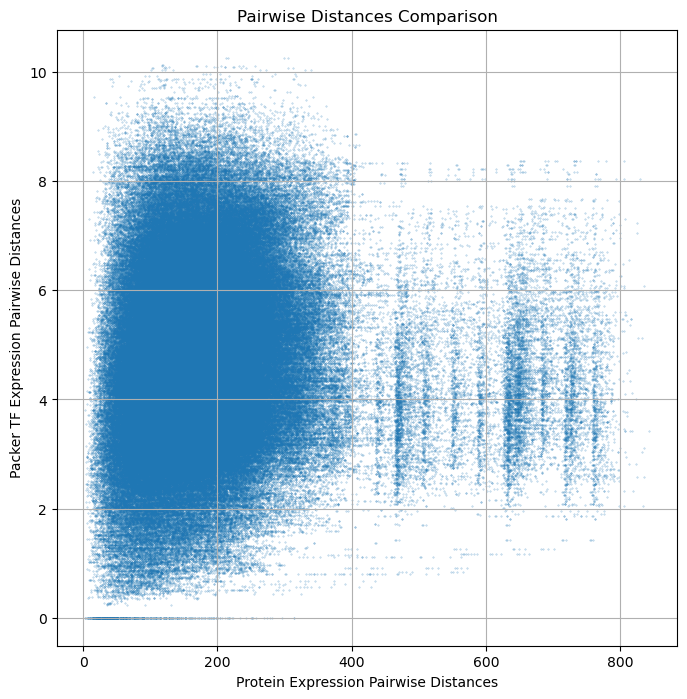

In [42]:
# plot two distances against each other
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
plt.scatter(protein_distances, packer_distances, alpha=0.5,s=0.1)
plt.xlabel("Protein Expression Pairwise Distances")
plt.ylabel("Packer TF Expression Pairwise Distances")
plt.title("Pairwise Distances Comparison")
plt.grid(True)
plt.show()

In [43]:
from scipy.stats import spearmanr
spearman_corr, p = spearmanr(protein_distances, packer_distances)
print(f"Spearman correlation between pairwise distances: {spearman_corr}, p-value: {p}")

Spearman correlation between pairwise distances: 0.1175337634384562, p-value: 0.0


In [25]:
max_time = 0
for lineage_name in packer_exp.columns:
    lineage_xyz_df = xyz_ts_df[xyz_ts_df["name"] == lineage_name]
    max_time = max(max_time, lineage_xyz_df["t"].max())

In [33]:
len(set(post_xyz_ts_df['lineage'].unique()).intersection(set(protein_df.columns)))

10

In [30]:
xyz_ts_df["t"].max()

np.int64(359)

In [48]:
raw_xyz_ts_df = pd.read_csv("./data/tracks.txt", sep="\t")

In [39]:
raw_xyz_ts_df[raw_xyz_ts_df["name"] == "ABprppapaap"]

,t,z,y,x,cell_id,parent_id,track_id,radius,name,div_state
40194,242,200.0,72.0,213.0,40002,39538,1,6.0,ABprppapaap,2
40669,243,198.0,71.0,221.0,40473,40002,1,6.0,ABprppapaap,0
41151,244,198.0,72.0,222.0,41298,40473,1,6.0,ABprppapaap,0
41639,245,198.0,72.0,223.0,41785,41298,1,6.0,ABprppapaap,0
42132,246,198.0,71.0,223.0,42279,41785,1,6.0,ABprppapaap,0
...,...,...,...,...,...,...,...,...,...,...
103858,355,142.0,95.0,214.0,103904,103326,1,6.0,ABprppapaap,0
104418,356,143.0,94.0,214.0,104484,103904,1,6.0,ABprppapaap,0
104998,357,143.0,94.0,215.0,105064,104484,1,6.0,ABprppapaap,0
105597,358,143.0,93.0,216.0,105642,105064,1,6.0,ABprppapaap,0


In [40]:
"ABprppapaap" in raw_xyz_ts_df[raw_xyz_ts_df["t"] == 242]['name'].values

True

In [41]:
lineage_exp = pd.read_csv("data/protein/aggregated_all/s3_lineage_umap_embedding_3d.csv", index_col=0)
lineage_exp.sample(3)

,ABa,ABal,ABala,ABalaa,ABalaaa,ABalaaaa,ABalaaaal,ABalaaaala,ABalaaaalal,ABalaaaalar,...,MSppppaa,MSppppap,MSppppp,MSpppppa,MSpppppp,P2,P3,P4,Z2,Z3
x2,1.076662,-6.042241,-5.893799,-5.935076,-6.140350,-6.466451,0.480536,5.377651,5.126419,5.315460,...,2.719384,2.692873,2.810501,2.896586,2.870686,-5.885324,-5.874525,-0.437833,-0.354125,-0.277430
x1,1.111727,-2.239822,-2.135620,-2.130679,-1.694884,-1.314266,-2.939248,-4.209399,-4.308650,-4.242414,...,15.165166,15.184664,14.899188,14.949531,14.868373,-2.348238,-2.118245,0.647994,0.722739,0.797947
x0,16.242653,6.325397,6.299764,6.316230,5.926972,5.488149,14.302826,13.382111,13.053475,13.300379,...,-3.450135,-3.443978,-3.083103,-3.161524,-3.047827,6.371909,6.310170,7.199604,7.161742,7.235652


In [42]:
raw_lineage_exp = pd.read_csv("data/protein/aggregated_all/s3.csv", index_col=0)
raw_lineage_exp.shape

(1204, 291)

In [43]:
def covered_terminal_nodes(terminal_nodes, ts_df, t_threshold=242):
    ts_df = ts_df.loc[ts_df["t"] <= t_threshold]
    cell_names = ts_df["name"].unique()
    valid_cell_names = []
    for name in cell_names:
        time_points = ts_df.loc[ts_df['name'] == name]["t"].values
        if len(time_points) == 1 and time_points[0] == t_threshold:
            continue
        valid_cell_names.append(name)
    return list(set(terminal_nodes) & set(valid_cell_names)), valid_cell_names
    

In [44]:
res, cells_in_ts = covered_terminal_nodes(terminal_nodes, xyz_ts_df, 280)
len(res)

478

In [ ]:
set(terminal_nodes).difference(set(raw_lineage_exp.index))

{'ABalappaapa', 'ABalappaapp'}

In [110]:
len(set(terminal_nodes).intersection(set(raw_lineage_exp.index)))

494

In [47]:
raw_xyz_ts_df.head(3)

,t,z,y,x,cell_id,parent_id,track_id,radius,name,div_state
0,0,144.0,126.0,109.0,3,-1,3,18.0,ABa,0
1,0,149.0,72.0,184.0,1,-1,1,16.5,ABp,0
2,0,132.0,123.0,292.0,2,-1,2,10.0,P2,0


In [107]:
raw_xyz_ts_df = pd.read_csv("./data/embryo3/tracks.txt", sep="\t")
embryo_name = "embryo3"
velocity_by_time_dict = defaultdict(list)
for name, group in raw_xyz_ts_df.groupby("name"):
    group.sort_values(by="t", inplace=True)
    for i in range(len(group) - 1):
        t1 = group.iloc[i]["t"]
        t2 = group.iloc[i + 1]["t"]
        if t2 - t1 == 1:
            velocity = (group.iloc[i + 1][["x", "y", "z"]] - group.iloc[i][["x", "y", "z"]]).values
            magnitude = np.linalg.norm(velocity)
            velocity_by_time_dict[t1].append((velocity, magnitude))

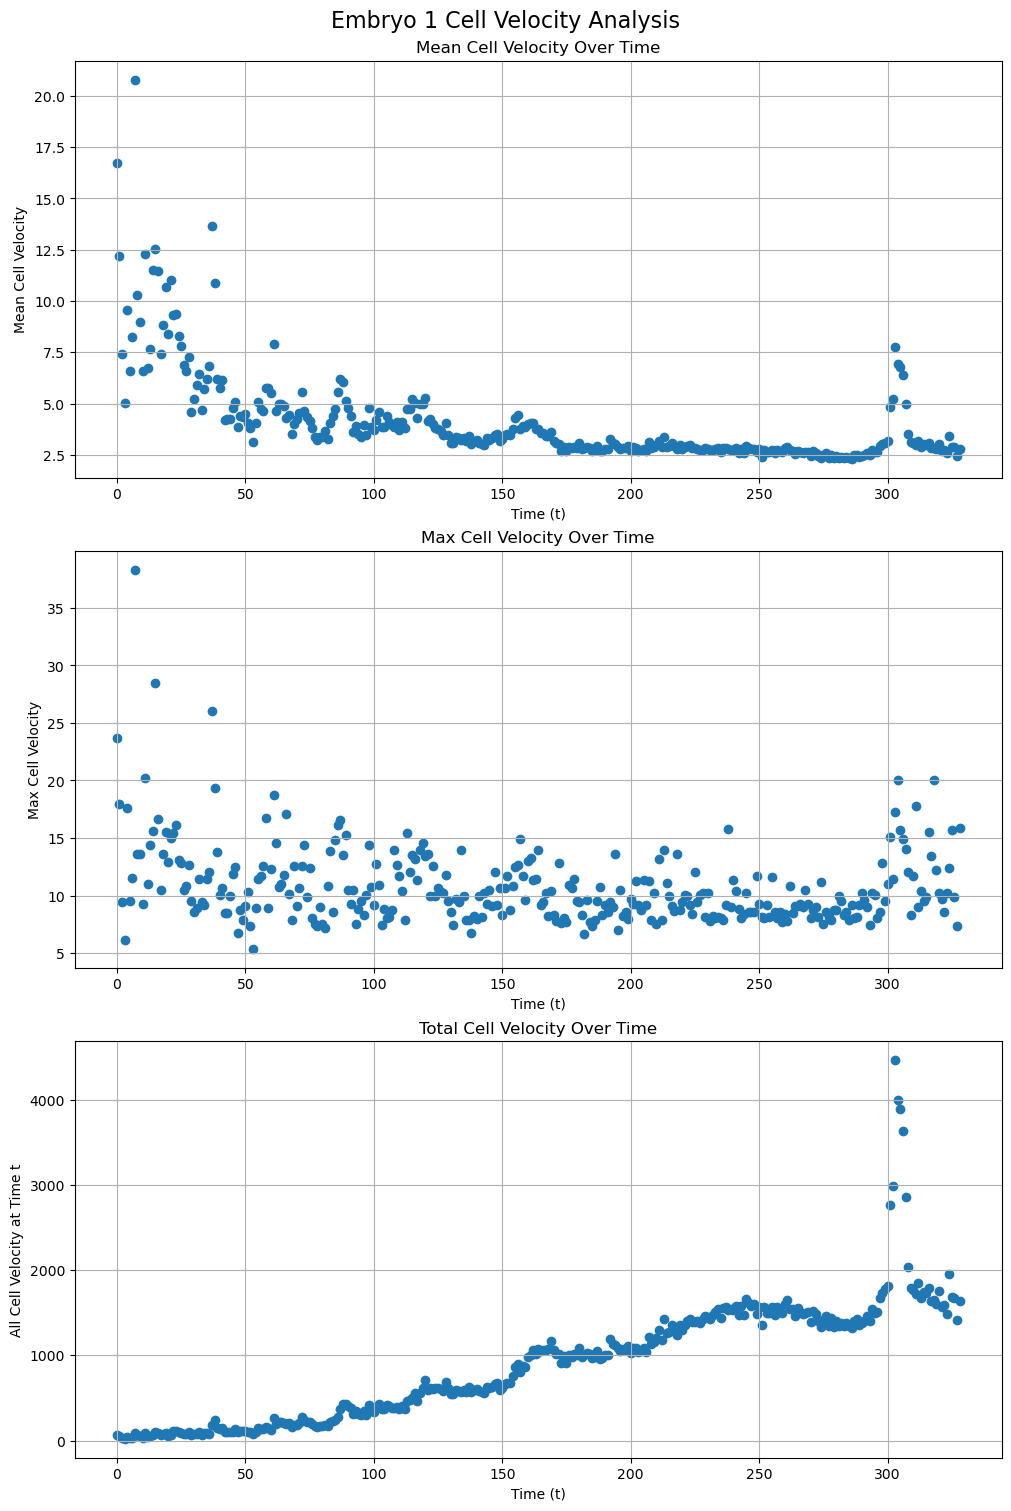

In [109]:
mean_velocity_list = []
max_velocity_list = []
min_velocity_list = []
total_velocity_list = []
time_list = []
for t, velocities in velocity_by_time_dict.items():
    if len(velocities) == 0:
        continue
    total_magnitude = np.sum([v[1] for v in velocities])
    mean_magnitude = total_magnitude / len(velocities)
    min_magnitude = np.min([v[1] for v in velocities])
    max_magnitude = np.max([v[1] for v in velocities])
    mean_velocity_list.append(mean_magnitude)
    max_velocity_list.append(max_magnitude)
    min_velocity_list.append(min_magnitude)
    total_velocity_list.append(total_magnitude)
    time_list.append(t)

# plotting the mean, max, and total velocities over time in a vertically stacked plot series
import matplotlib.pyplot as plt
fig, axs = plt.subplots(3, 1, constrained_layout=True, figsize=(10, 15))
fig.suptitle('Embryo 1 Cell Velocity Analysis', fontsize=16)
axs[0].scatter(time_list, mean_velocity_list, marker='o')
axs[0].set_title('Mean Cell Velocity Over Time')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Mean Cell Velocity')
axs[0].grid()

axs[1].scatter(time_list, max_velocity_list, marker='o')
axs[1].set_title('Max Cell Velocity Over Time')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Max Cell Velocity')
axs[1].grid()

axs[2].scatter(time_list, total_velocity_list, marker='o')
axs[2].set_title('Total Cell Velocity Over Time')
axs[2].set_xlabel('Time (t)')
axs[2].set_ylabel('All Cell Velocity at Time t')
axs[2].grid()
plt.show()
fig.savefig(f"./output/{embryo_name}_cell_velocity_over_time.png", dpi=400)